<a href="https://colab.research.google.com/github/giantary/2026LE17_BackgroundKnowledge/blob/main/Mini_project/DL_Project/3_unet_segmentation_en.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 3: Medical Image Segmentation with UNet
# Polyp Segmentation from Endoscopic Images (Kvasir-SEG Dataset)

**Goal:** Build a UNet11 model (based on VGG-11 encoder) to automatically segment polyp regions in gastrointestinal endoscopy images.

**Author:** Trầm Tính Ân - 24520074

---


## Setup and Imports


In [11]:
# Download Kvasir-SEG dataset (if on Kaggle/Colab)
!wget --no-check-certificate https://datasets.simula.no/downloads/kvasir-seg.zip
!unzip -q kvasir-seg.zip -d data/
# Note: Update the ROOT_DIR variable below to point to the extracted folder.


--2026-09-15 10:36:34--  https://datasets.simula.no/downloads/kvasir-seg.zip
Resolving datasets.simula.no (datasets.simula.no)... 128.39.36.14
Connecting to datasets.simula.no (datasets.simula.no)|128.39.36.14|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 46227172 (44M) [application/zip]
Saving to: ‘kvasir-seg.zip’

kvasir-seg.zip      100%[===================>]  44.08M  3.86MB/s    in 13s     

2026-09-15 10:36:48 (3.37 MB/s) - ‘kvasir-seg.zip’ saved [46227172/46227172]



In [12]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


---
## Exercise 1: Data Visualization

Read and display a few pairs of original images and ground truth masks.


In [13]:
ROOT_DIR = "data/Kvasir-SEG" # Change this path if needed
IMAGE_DIR = os.path.join(ROOT_DIR, "images")
MASK_DIR = os.path.join(ROOT_DIR, "masks")

# Get file lists
if os.path.exists(IMAGE_DIR):
    image_files = sorted(os.listdir(IMAGE_DIR))
    mask_files = sorted(os.listdir(MASK_DIR))
    print(f"Found {len(image_files)} images.")
else:
    print(f"Directory {IMAGE_DIR} not found. Please download dataset first.")
    image_files, mask_files = [], []


Found 1000 images.


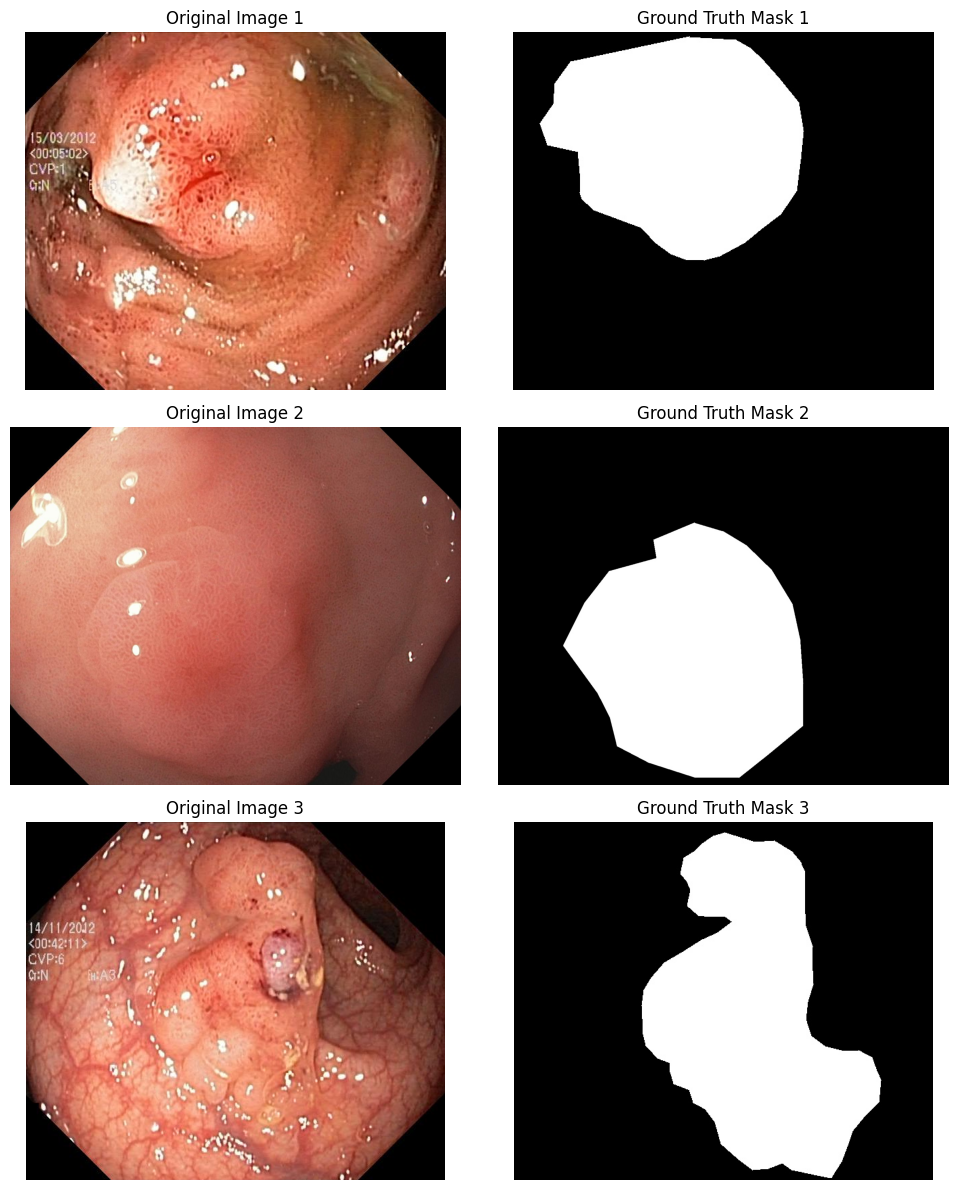

In [14]:
# --- EXERCISE 1 ---
def visualize_samples(image_dir, mask_dir, filenames, num_samples=3):
    """Function to display image and mask pairs"""
    if not filenames: return

    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4 * num_samples))
    for i in range(num_samples):
        img_path = os.path.join(image_dir, filenames[i])
        mask_path = os.path.join(mask_dir, filenames[i])

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"Original Image {i+1}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask, cmap="gray")
        axes[i, 1].set_title(f"Ground Truth Mask {i+1}")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

visualize_samples(IMAGE_DIR, MASK_DIR, image_files, num_samples=3)


---
## Exercise 2: Dataset & Data Transform

Create Dataset class and apply preprocessing:
- Resize to 224x224
- Normalize image using ImageNet statistics
- Binarize mask


In [15]:
# --- EXERCISE 2 ---
class PolypDataset(Dataset):
    def __init__(self, image_dir, mask_dir, filenames):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.filenames = filenames
        self.size = (224, 224)

        # Transform for images (Resize -> ToTensor -> Normalize)
        self.img_transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize(self.size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

        # Transform for masks (Resize -> ToTensor)
        self.mask_transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize(self.size),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        img_name = self.filenames[idx]

        img_path = os.path.join(self.image_dir, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = self.img_transform(img)

        mask_path = os.path.join(self.mask_dir, img_name)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = self.mask_transform(mask)

        # Binarize mask: Values to {0, 1}
        mask = torch.where(mask > 0.5, torch.tensor(1.0), torch.tensor(0.0))

        return img, mask


In [16]:
if image_files:
    # Split train/val/test ratio 60/20/20
    train_files, temp_files = train_test_split(image_files, test_size=0.4, random_state=42)
    val_files, test_files = train_test_split(temp_files, test_size=0.5, random_state=42)

    train_dataset = PolypDataset(IMAGE_DIR, MASK_DIR, train_files)
    val_dataset = PolypDataset(IMAGE_DIR, MASK_DIR, val_files)
    test_dataset = PolypDataset(IMAGE_DIR, MASK_DIR, test_files)

    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

    print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}, Test size: {len(test_dataset)}")


Train size: 600, Val size: 200, Test size: 200


---
## Exercise 3: Build UNet11 Model

Use VGG-11 (pre-trained) as the Encoder. The UNet architecture is U-shaped with skip connections.


In [17]:
class DecoderBlock(nn.Module):
    """Basic Decoder Block: ConvTranspose2d -> ReLU -> Conv2d -> ReLU"""
    def __init__(self, in_channels, middle_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)

# --- EXERCISE 3 ---
class UNet11(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()
        # Load pre-trained VGG-11
        vgg = models.vgg11(pretrained=True).features

        # Encoder
        self.enc1 = vgg[0:3]
        self.enc2 = vgg[3:6]
        self.enc3 = vgg[6:11]
        self.enc4 = vgg[11:16]
        self.enc5 = vgg[16:21]

        # Center
        self.center = DecoderBlock(512, 512, 256)

        # Decoder (receives skip connections)
        self.dec5 = DecoderBlock(512 + 256, 512, 256)
        self.dec4 = DecoderBlock(256 + 256, 256, 128)
        self.dec3 = DecoderBlock(128 + 128, 128, 64)
        self.dec2 = DecoderBlock(64 + 64, 64, 32)

        self.dec1 = nn.Sequential(
            nn.Conv2d(32 + 3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

        self.final = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, x):
        # Encoder pass
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        e5 = self.enc5(e4)

        # Center
        c = self.center(e5)

        # Decoder pass with Skip Connections
        d5 = self.dec5(torch.cat([c, e4], dim=1))
        d4 = self.dec4(torch.cat([d5, e3], dim=1))
        d3 = self.dec3(torch.cat([d4, e2], dim=1))
        d2 = self.dec2(torch.cat([d3, e1], dim=1))

        d1 = self.dec1(torch.cat([d2, x], dim=1))

        out = self.final(d1)
        return out

model = UNet11().to(device)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")


Total parameters: 12,260,065


---
## Exercise 4: Model Evaluation (IoU)

Implement the Intersection over Union (IoU) metric, also known as the Jaccard Index.
Formula: `IoU = Intersection / Union`


In [18]:
# --- EXERCISE 4 ---
def compute_iou(y_pred, y_true):
    """
    Compute IoU.
    y_pred: tensor (after sigmoid), shape [B, 1, H, W]
    y_true: tensor (labels), shape [B, 1, H, W]
    """
    # Convert prediction to binary using 0.5 threshold
    y_pred_bin = (y_pred > 0.5).float()

    intersection = (y_pred_bin * y_true).sum(dim=(2, 3))
    union = y_pred_bin.sum(dim=(2, 3)) + y_true.sum(dim=(2, 3)) - intersection

    # Avoid division by zero
    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.mean().item()


---
## Training Phase


In [19]:
# BCEWithLogitsLoss includes Sigmoid activation
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=4e-5, weight_decay=1e-4)

EPOCHS = 20

def train_one_epoch(model, dataloader, optimizer, criterion):
    model.train()
    total_loss = 0
    total_iou = 0

    for inputs, targets in tqdm(dataloader, desc="Training"):
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)

        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_iou += compute_iou(torch.sigmoid(outputs), targets)

    return total_loss / len(dataloader), total_iou / len(dataloader)

def validate(model, dataloader, criterion):
    model.eval()
    total_loss = 0
    total_iou = 0

    with torch.no_grad():
        for inputs, targets in tqdm(dataloader, desc="Validation"):
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)

            loss = criterion(outputs, targets)
            total_loss += loss.item()
            total_iou += compute_iou(torch.sigmoid(outputs), targets)

    return total_loss / len(dataloader), total_iou / len(dataloader)



Epoch 1/20


Validation: 100%|██████████| 13/13 [00:02<00:00,  5.41it/s]


Train Loss: 0.6480 | Train IoU: 0.0372
Val Loss:   0.4784 | Val IoU:   0.0000

Epoch 2/20


Validation: 100%|██████████| 13/13 [00:02<00:00,  4.56it/s]


Train Loss: 0.4203 | Train IoU: 0.0000
Val Loss:   0.3859 | Val IoU:   0.0000

Epoch 3/20


...

Train Loss: 0.0535 | Train IoU: 0.8260
Val Loss:   0.2202 | Val IoU:   0.6543

Epoch 19/20


Validation: 100%|██████████| 13/13 [00:02<00:00,  5.35it/s]


Train Loss: 0.0466 | Train IoU: 0.8451
Val Loss:   0.2205 | Val IoU:   0.6618

Epoch 20/20


Validation: 100%|██████████| 13/13 [00:02<00:00,  4.46it/s]


Train Loss: 0.0427 | Train IoU: 0.8551
Val Loss:   0.2590 | Val IoU:   0.6480


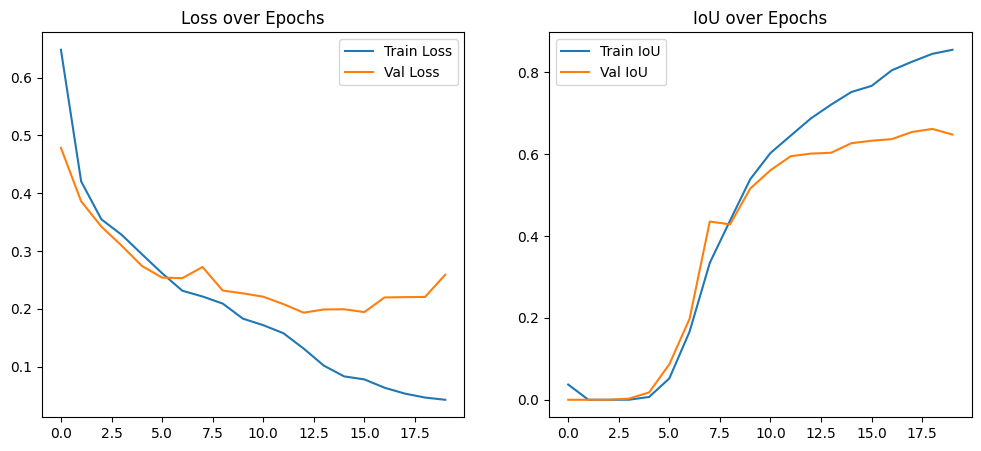

Validation: 100%|██████████| 13/13 [00:02<00:00,  5.26it/s]


--- TEST SET EVALUATION ---
Test Loss: 0.2223 | Test IoU: 0.6657
Training code is ready. Download dataset and run!


In [20]:
train_losses, val_losses = [], []
train_ious, val_ious = [], []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    train_loss, train_iou = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_iou = validate(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_ious.append(train_iou)
    val_ious.append(val_iou)

    print(f"Train Loss: {train_loss:.4f} | Train IoU: {train_iou:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val IoU:   {val_iou:.4f}")

# Plot Loss and IoU
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_ious, label='Train IoU')
plt.plot(val_ious, label='Val IoU')
plt.title('IoU over Epochs')
plt.legend()
plt.show()

# Evaluate on Test set
test_loss, test_iou = validate(model, test_loader, criterion)
print(f"\n--- TEST SET EVALUATION ---")
print(f"Test Loss: {test_loss:.4f} | Test IoU: {test_iou:.4f}")
print("Training code is ready. Download dataset and run!")


---
## Inference & Visualization

Function to predict and plot the output mask alongside the original image.


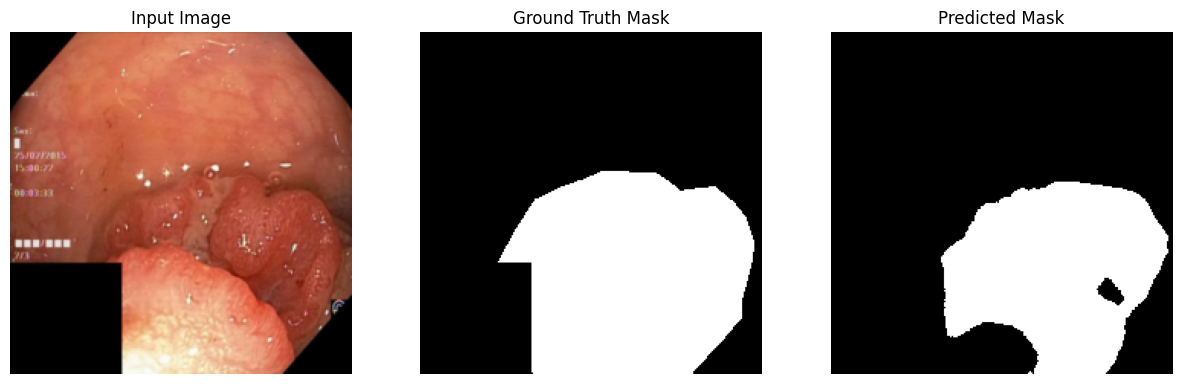

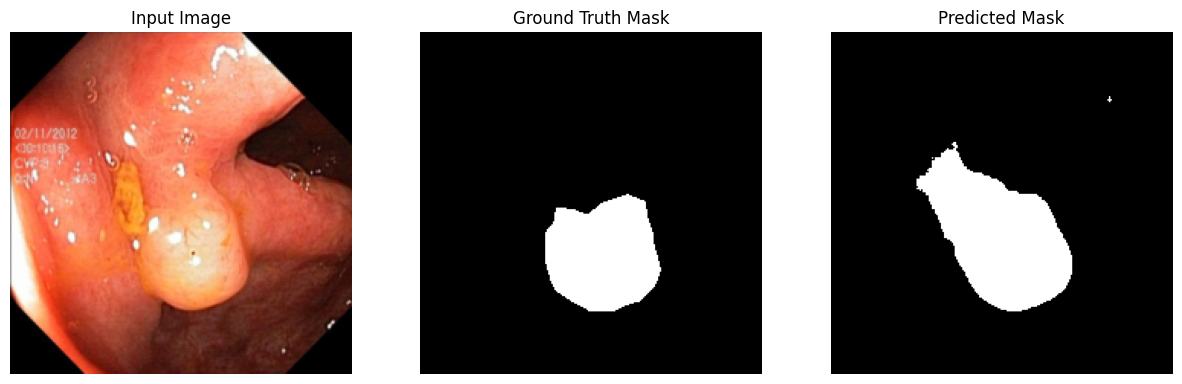

In [22]:
def visualize_prediction(model, dataset, idx):
    if not image_files: return
    model.eval()

    img_tensor, mask_tensor = dataset[idx]

    with torch.no_grad():
        out = model(img_tensor.unsqueeze(0).to(device))
        pred_mask = torch.sigmoid(out).squeeze().cpu().numpy()
        pred_bin = (pred_mask > 0.5).astype(np.float32)

    # Prepare image for plotting
    img_show = img_tensor.permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_show = std * img_show + mean
    img_show = np.clip(img_show, 0, 1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_show)
    axes[0].set_title("Input Image")
    axes[0].axis('off')

    axes[1].imshow(mask_tensor.squeeze(), cmap='gray')
    axes[1].set_title("Ground Truth Mask")
    axes[1].axis('off')

    axes[2].imshow(pred_bin, cmap='gray')
    axes[2].set_title("Predicted Mask")
    axes[2].axis('off')

    plt.show()


visualize_prediction(model, test_dataset, 0)
visualize_prediction(model, test_dataset, 1)


---
## Clinical Evaluation

In practice, the model may make incorrect predictions (False Positives) in certain cases. For example, the AI might identify a normal colon fold as a polyp because the fold is **protruding and catching the light from the endoscope, creating a shiny reflection (Specular highlight)**. A protruding structure with a shiny surface closely mimics the visual features of a polyp that the AI has learned.

This is a known limitation of analyzing static 2D images. In a clinical setting, doctors can wash the area, observe it from multiple angles via video, or switch lighting modes to confirm. However, as a screening tool, having a highly sensitive AI (which prefers to "over-flag" areas for doctors to double-check rather than miss a potential lesion) is a highly desirable characteristic.

